# Import Libraries

In [ ]:
import numpy as np
from skimage import io, color, exposure, img_as_float
import matplotlib.pyplot as plt

In [ ]:
def plot_hist(I, nbins=256, normalize=False, plot_cdf=True):
    hist, bins_hist = exposure.histogram(I.ravel(), nbins=nbins, normalize=normalize)
    plt.plot(bins_hist, hist, 'k')
    plt.xlabel("pixel values")
    if normalize:
        plt.ylabel("probability")
    else:
        plt.ylabel("count")
    xmax = 1 if I.max() <= 1 else 255
    plt.xlim([0, xmax])

    if plot_cdf:
        cdf, bins_cdf = exposure.cumulative_distribution(I.ravel(), nbins=nbins)
        plt.twinx()
        plt.plot(bins_cdf, cdf, 'r', lw=3)
        plt.ylabel("percentage")

In [ ]:
def plot_img_and_hist(I, nbins=256, normalize=False, plot_cdf=True, figsize=(12, 6)):
    fig, ax = plt.subplots(2, 1, figsize=figsize)
    plt.subplot(2, 1, 1)
    io.imshow(I)
    plt.axis("off")
    plt.title("image")

    plt.subplot(2, 1, 2)
    plot_hist(I, nbins=nbins, normalize=normalize, plot_cdf=plot_cdf)
    plt.title("histogram")

# Task 1

<ipython-input-4-6b7ed97258bb>:20: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)


Text(0.5, 1.0, 'cumulative histogram')

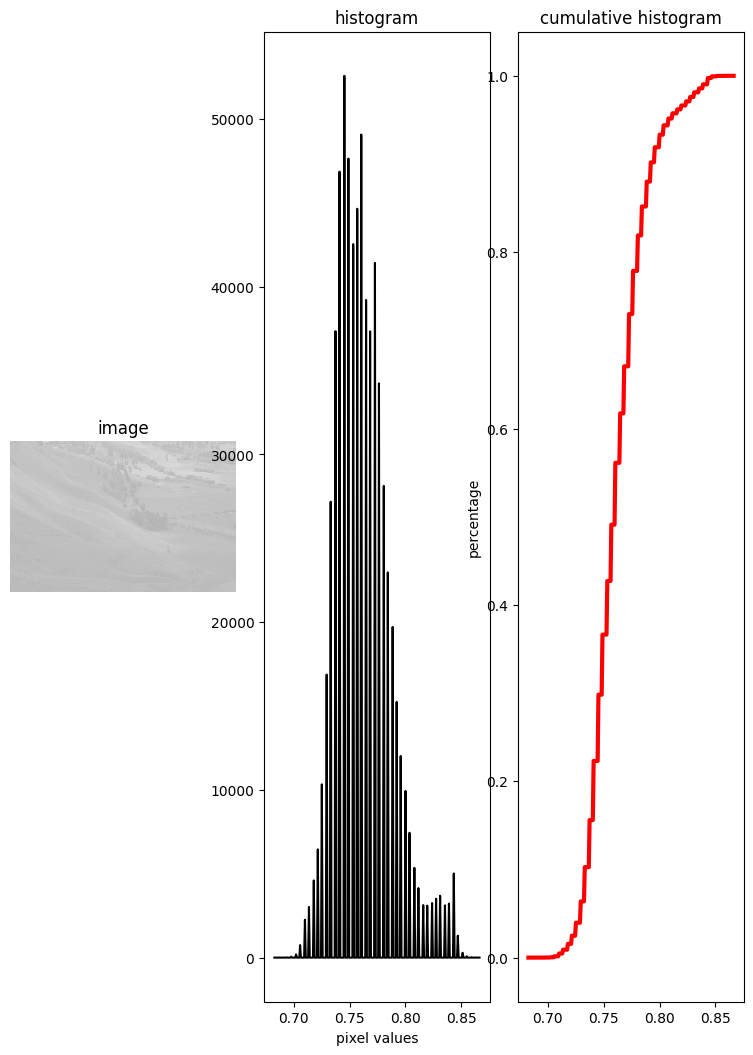

In [ ]:
# Load the "land.jpeg" image
I = io.imread("land.jpeg")

# Normalize the image using img_to_float
I = img_as_float(I)

# Calculate the histogram
hist, bins = exposure.histogram(I.ravel(), nbins= 256, normalize= False)

# Calculate the cumulative histogram
chist, cbins = exposure.cumulative_distribution(I.ravel(), nbins=256)

# In a 1 by 3 subplots (plt.subplots(1, 3, ...)), show:
# 1. The image (note that the image is grayscale)
# 2. Histogram
# 3. Cumulative histogram

plt.rcParams['figure.figsize'] = (8, 10)
plt.subplot(1, 3, 1)
io.imshow(I)
plt.axis("off")
plt.title("image")

plt.subplot(1, 3, 2)
plt.plot(bins, hist, 'k')
plt.xlabel("pixel values")
plt.title("histogram")
plt.subplot(1, 3, 3)

plt.plot(cbins,chist, 'r', lw=3)
plt.ylabel("percentage")
plt.title("cumulative histogram")

# Task 2

In [ ]:
# Perform global histogram equalization on the image
I_histeq = exposure.equalize_hist(I)
hist_I_histeq, bins_I_histeq = exposure.histogram(I_histeq, nbins= 256, normalize= False)
# Perform adaptive histogram equalization (AHE) with kernel size = (41, 41)
I_ahe = exposure.equalize_adapthist(I, kernel_size=(41, 41), clip_limit=0)
hist_I_ahe, bins_I_ahe = exposure.histogram(I_ahe, nbins= 256, normalize= False)
# Perform CLAHE with kernel size = (41, 41) and clip limit = 0.05
I_clahe = exposure.equalize_adapthist(I, kernel_size=(41, 41), clip_limit=0.05)
hist_I_clahe, bins_I_clahe = exposure.histogram(I_clahe, nbins=256)

<ipython-input-18-063f9b5d36ed>:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I)
<ipython-input-18-063f9b5d36ed>:12: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I_histeq )
<ipython-input-18-063f9b5d36ed>:17: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I_ahe )
<ipython-input-18-063f9b5d36ed>:22: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I_clahe)


Text(0.5, 1.0, 'hist(I_clahe)')

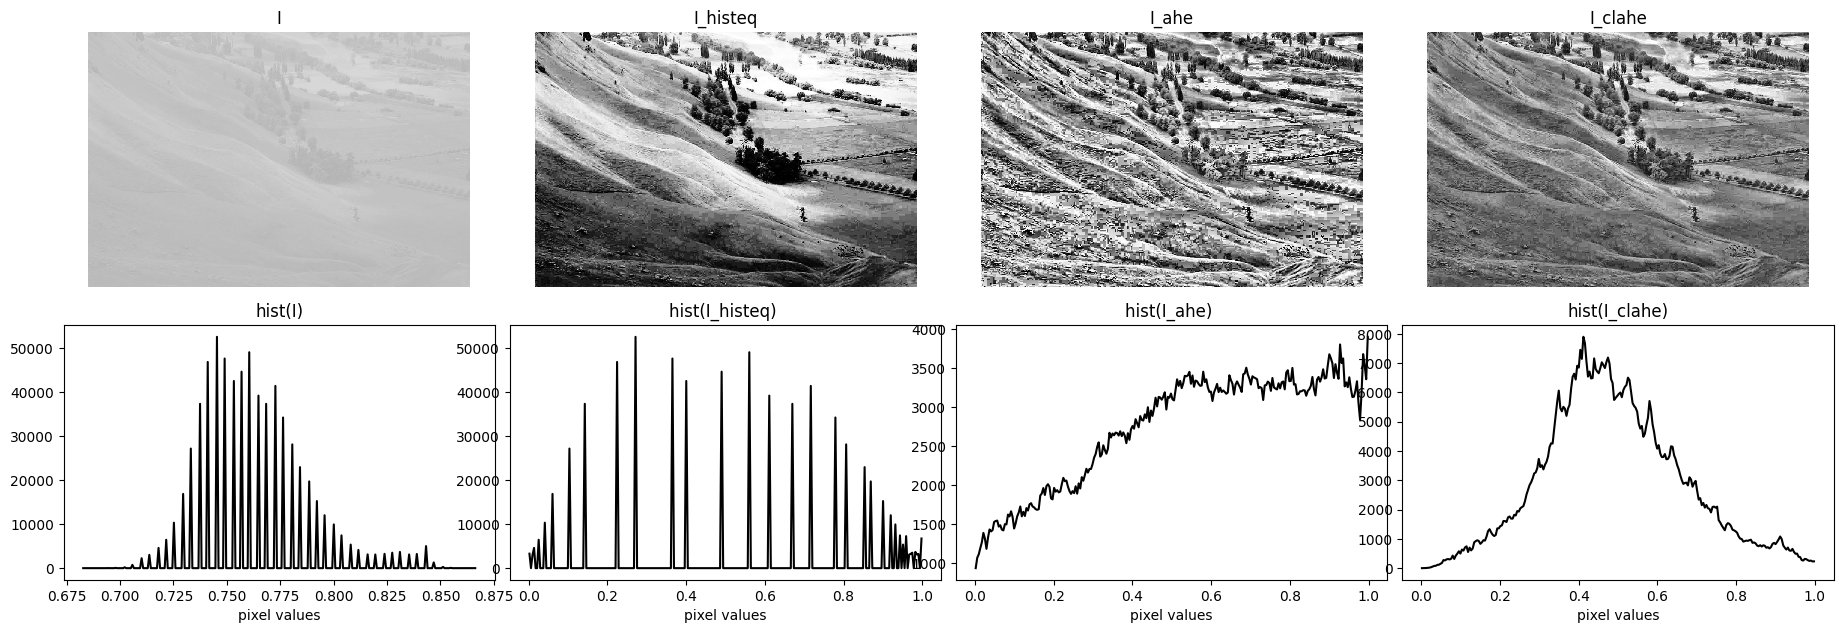

In [ ]:
# In a 2 by 4 subplots (plt.subplots(1, 3, ...)), show the followings:
#    I           I_histeq           I_ahe          I_clahe
# hist(I)     hist(I_histeq)     hist(I_ahe)    hist(I_clahe)

plt.rcParams['figure.figsize'] = (18,6)
plt.subplot(2, 4, 1)
io.imshow(I)
plt.axis("off")
plt.title("I")

plt.subplot(2, 4, 2)
io.imshow(I_histeq )
plt.axis("off")
plt.title("I_histeq")

plt.subplot(2, 4, 3)
io.imshow(I_ahe )
plt.axis("off")
plt.title("I_ahe")

plt.subplot(2, 4, 4)
io.imshow(I_clahe)
plt.axis("off")
plt.title("I_clahe")

plt.subplot(2, 4, 5)
plt.plot(bins, hist, 'k')
plt.xlabel("pixel values")
plt.title("hist(I)")

plt.subplot(2, 4,6)
plt.plot(bins_I_histeq,hist_I_histeq , 'k')
plt.xlabel("pixel values")
plt.title("hist(I_histeq) ")

plt.subplot(2, 4, 7)
plt.plot(bins_I_ahe ,hist_I_ahe, 'k')
plt.xlabel("pixel values")
plt.title("hist(I_ahe) ")

plt.subplot(2, 4, 8)
plt.plot(bins_I_clahe,hist_I_clahe, 'k')
plt.xlabel("pixel values")
plt.title("hist(I_clahe)")